# Lab 11 – Support Vector Machines

Scored task: **4 points**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score

## Task 1: Linear SVM and Logistic Regression

### Dataset Generation

In [2]:
np.random.seed(42)
n_strip = 16
n_blob = 6000

# Class 0
x0_1 = np.hstack([
    np.random.normal(scale=0.6, size=(n_strip, 1)),
    np.random.uniform(0.3, 0.8, size=(n_strip, 1))
])
x0_2 = np.random.multivariate_normal(
    mean=[0, 10],
    cov=np.array([[4, 3.5], [3.5, 4]]),
    size=n_blob
)
X0 = np.vstack([x0_1, x0_2])
y0 = np.zeros(n_strip + n_blob)

# Class 1
x1_1 = np.hstack([
    np.random.normal(scale=0.6, size=(n_strip, 1)),
    np.random.uniform(-0.8, -0.3, size=(n_strip, 1))
])
x1_2 = np.random.multivariate_normal(
    mean=[0, -10],
    cov=np.array([[4, 3.5], [3.5, 4]]),
    size=n_blob
)
X1 = np.vstack([x1_1, x1_2])
y1 = np.ones(n_strip + n_blob)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])
print(f'Total samples: {X.shape[0]}, Features: {X.shape[1]}')

Total samples: 12032, Features: 2


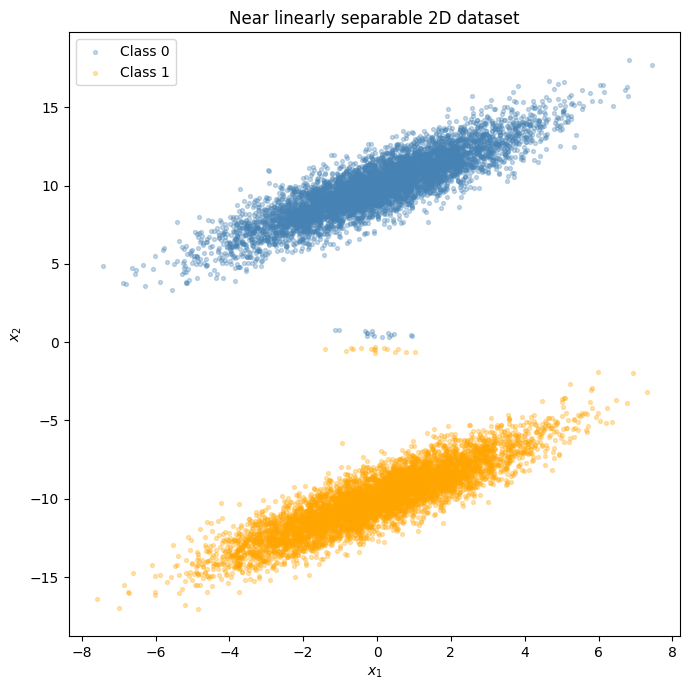

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', alpha=0.3, s=8, label='Class 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='orange', alpha=0.3, s=8, label='Class 1')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Near linearly separable 2D dataset')
ax.legend()
plt.tight_layout()
plt.show()

### Train/Test Split and Standardisation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler1 = StandardScaler()
X_train_sc = scaler1.fit_transform(X_train)
X_test_sc  = scaler1.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples')

Train: 9625 samples | Test: 2407 samples


### Fit Models

In [5]:
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X_train_sc, y_train)

svm_lin = SVC(kernel='linear', C=1.0)
svm_lin.fit(X_train_sc, y_train)

for name, clf in [('Logistic Regression', lr1), ('Linear SVM (C=1)', svm_lin)]:
    tr = accuracy_score(y_train, clf.predict(X_train_sc))
    te = accuracy_score(y_test,  clf.predict(X_test_sc))
    print(f'{name:<25}  train={tr:.4f}  test={te:.4f}')

Logistic Regression        train=0.9997  test=0.9988
Linear SVM (C=1)           train=0.9990  test=0.9983


### Decision Regions

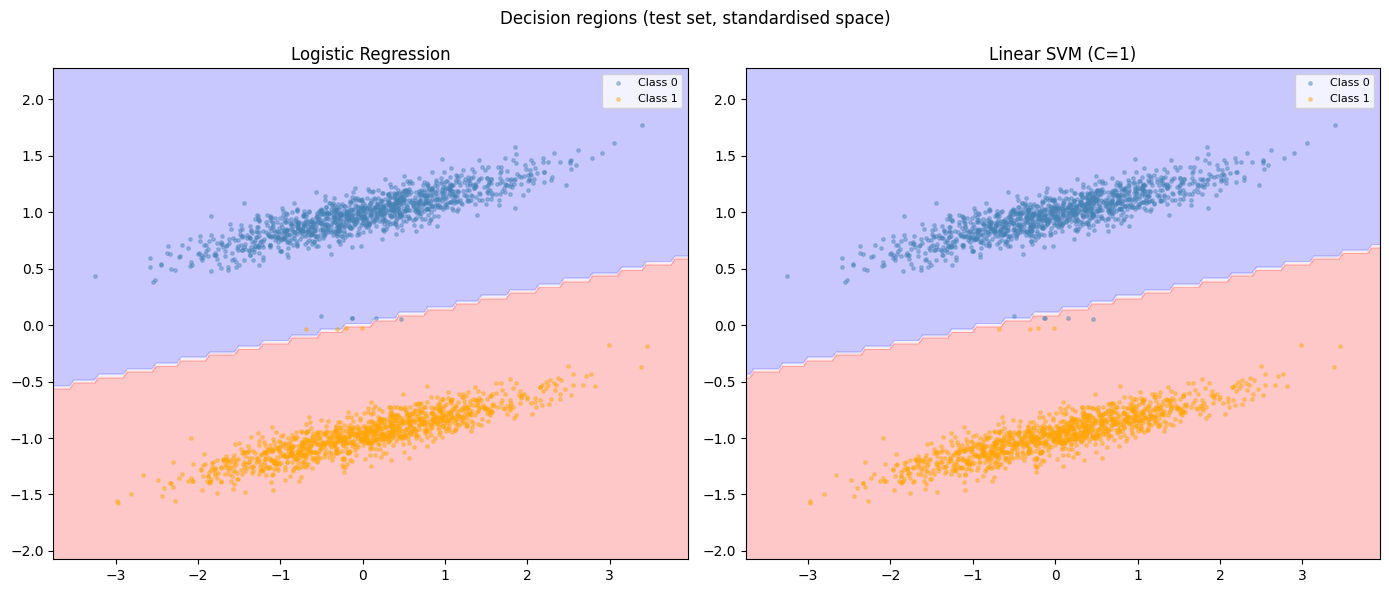

In [6]:
def plot_decision_regions(X, y, clf, ax, title, resolution=0.05):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, resolution),
                         np.arange(x1_min, x1_max, resolution))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='bwr')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', alpha=0.4, s=6, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='orange',    alpha=0.4, s=6, label='Class 1')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_regions(X_test_sc, y_test, lr1,     axes[0], 'Logistic Regression')
plot_decision_regions(X_test_sc, y_test, svm_lin, axes[1], 'Linear SVM (C=1)')
plt.suptitle('Decision regions (test set, standardised space)')
plt.tight_layout()
plt.show()

### SVM: Hyperplane, Margin Lines, and Support Vectors

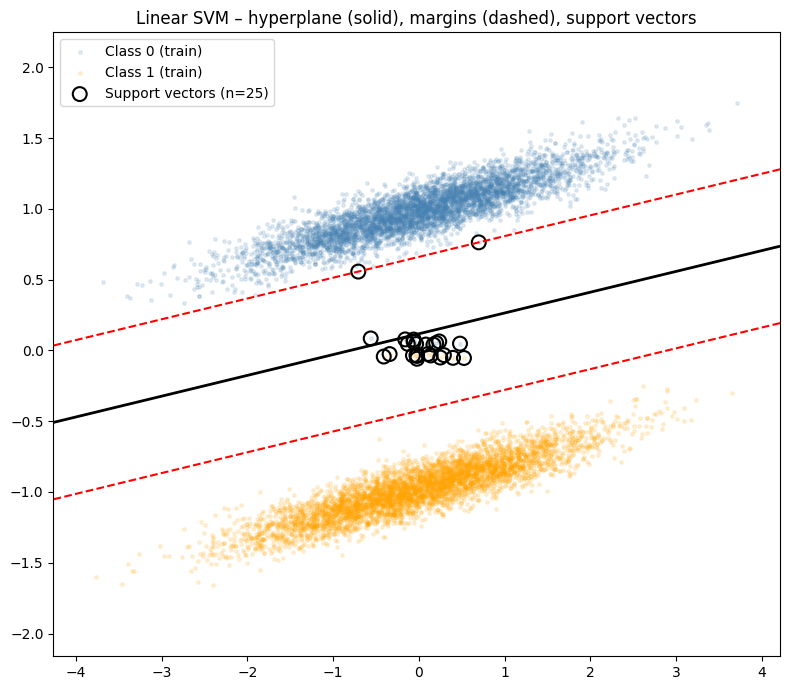

Number of support vectors: 25 (class 0: 13, class 1: 12)


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_train_sc[y_train == 0, 0], X_train_sc[y_train == 0, 1],
           c='steelblue', alpha=0.15, s=6, label='Class 0 (train)')
ax.scatter(X_train_sc[y_train == 1, 0], X_train_sc[y_train == 1, 1],
           c='orange', alpha=0.15, s=6, label='Class 1 (train)')

x0_min = X_train_sc[:, 0].min() - 0.5
x0_max = X_train_sc[:, 0].max() + 0.5
x1_min = X_train_sc[:, 1].min() - 0.5
x1_max = X_train_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                     np.linspace(x1_min, x1_max, 300))
Z = svm_lin.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, Z, levels=[-1, 0, 1],
           linestyles=['--', '-', '--'],
           colors=['red', 'black', 'red'],
           linewidths=[1.5, 2.0, 1.5])

sv = svm_lin.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k',
           linewidths=1.5, label=f'Support vectors (n={len(sv)})')

ax.set_xlim(x0_min, x0_max)
ax.set_ylim(x1_min, x1_max)
ax.set_title('Linear SVM – hyperplane (solid), margins (dashed), support vectors')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Number of support vectors: {len(sv)} (class 0: {svm_lin.n_support_[0]}, class 1: {svm_lin.n_support_[1]})')

### Effect of the C Parameter

     C    n_SV   train acc    test acc
--------------------------------------
  0.01     198      0.9997      0.9988
   0.1      44      0.9997      0.9983
     1      25      0.9990      0.9983
    10      22      1.0000      1.0000
   100       8      1.0000      1.0000


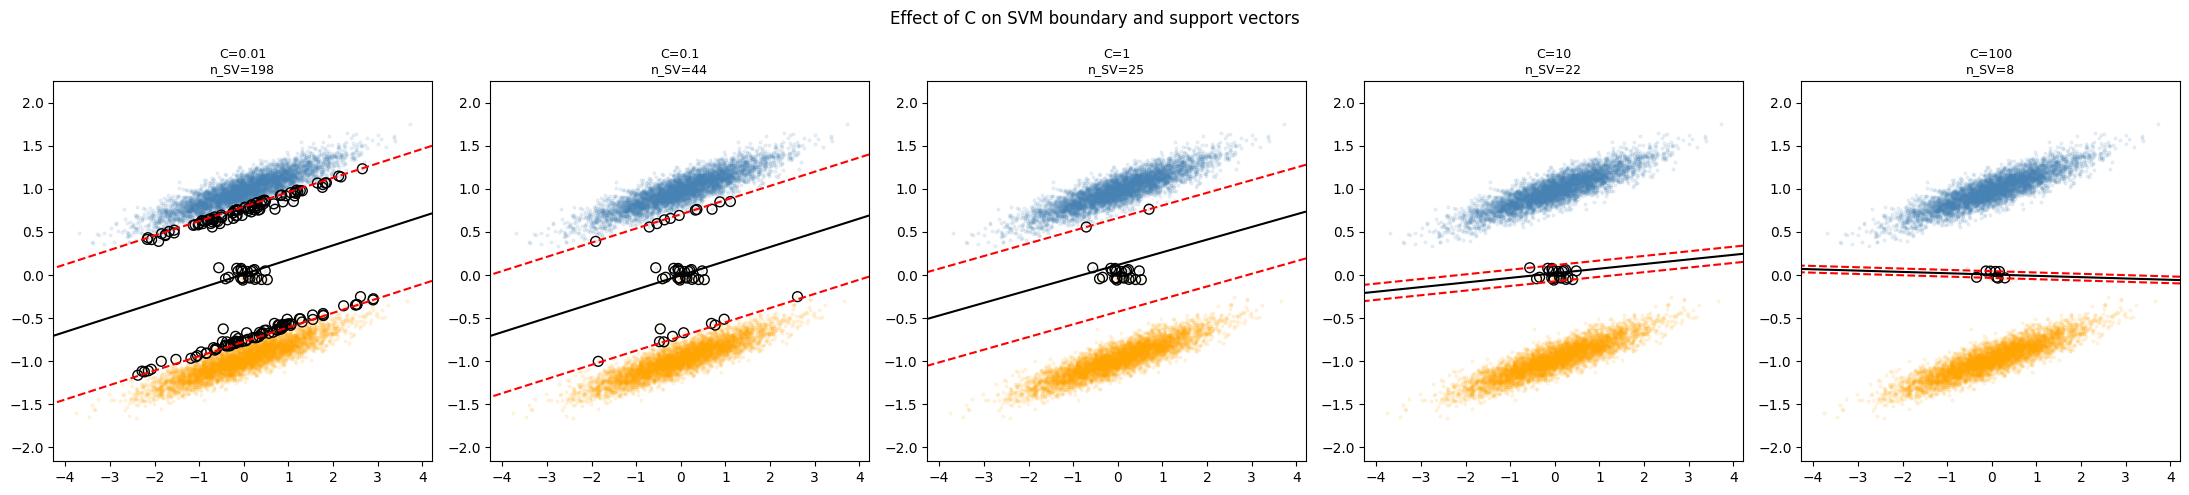

In [8]:
C_values = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, len(C_values), figsize=(22, 5))

xx2, yy2 = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                       np.linspace(x1_min, x1_max, 200))

print('{:>6}  {:>6}  {:>10}  {:>10}'.format('C', 'n_SV', 'train acc', 'test acc'))
print('-' * 38)
for ax, C in zip(axes, C_values):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_train_sc, y_train)
    Z2 = clf.decision_function(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    ax.scatter(X_train_sc[y_train == 0, 0], X_train_sc[y_train == 0, 1],
               c='steelblue', alpha=0.1, s=4)
    ax.scatter(X_train_sc[y_train == 1, 0], X_train_sc[y_train == 1, 1],
               c='orange', alpha=0.1, s=4)
    ax.contour(xx2, yy2, Z2, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'], colors=['red', 'k', 'red'])
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=50, facecolors='none', edgecolors='k')
    n_sv = len(clf.support_vectors_)
    tr = accuracy_score(y_train, clf.predict(X_train_sc))
    te = accuracy_score(y_test,  clf.predict(X_test_sc))
    ax.set_title(f'C={C}\nn_SV={n_sv}', fontsize=9)
    ax.set_xlim(x0_min, x0_max)
    ax.set_ylim(x1_min, x1_max)
    print(f'{C:>6}  {n_sv:>6}  {tr:>10.4f}  {te:>10.4f}')

plt.suptitle('Effect of C on SVM boundary and support vectors')
plt.tight_layout()
plt.show()

### Questions and Answers

**(a) Both methods use linear decision boundaries. Why are the boundaries different?**

Logistic regression is influenced by every observation, including the large clusters far from the boundary — their sheer volume pulls the boundary. SVM only cares about the points closest to the boundary and ignores everything far away, so the two boundaries end up in different places.

**(b) Which observations become support vectors?**

The points from the thin strips near the center of the plot, which sit closest to the separating boundary. A handful of points from the large blobs that happen to land near the boundary may also become support vectors.

**(c) Are support vectors necessarily misclassified observations?**

No. A support vector is any point that lies on or inside the margin zone, whether correctly classified or not. A correctly classified point can still be a support vector if it falls close enough to the boundary.

**(d) Does linear SVM estimate posterior probabilities P(Y = 1 | X = x)?**

No. SVM outputs a score that measures how far a point is from the boundary, not a probability. An extra calibration step must be added on top if probabilities are needed.

**(e) Why does the SVM boundary depend mainly on observations close to the separating boundary, while logistic regression is influenced by all observations?**

SVM uses a loss that becomes exactly zero for any correctly classified point far enough from the boundary, so those points contribute nothing to the solution. Logistic regression's loss is never exactly zero, so every observation always nudges the boundary slightly regardless of how far away it is.

**(f) How does the SVM boundary depend on C?**

A small C allows many points to sit inside the margin, producing a wider and smoother boundary. A large C penalises any margin violation heavily, making the boundary narrower and more sensitive to the few points near it.

**(g) Number of support vectors for each C:** see the printed table above.

---
## Task 2: Kernel SVM

### Dataset Generation

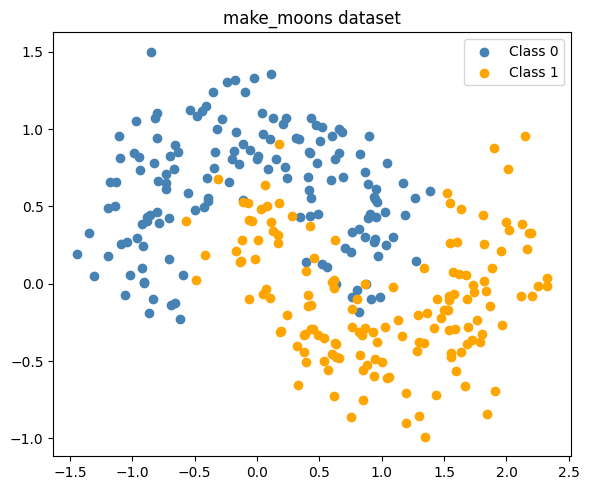

In [9]:
X2, y2 = make_moons(n_samples=300, noise=0.25, random_state=123)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], c='steelblue', label='Class 0')
ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], c='orange',    label='Class 1')
ax.set_title('make_moons dataset')
ax.legend()
plt.tight_layout()
plt.show()

### Train/Test Split and Standardisation

In [10]:
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_tr_sc = scaler2.fit_transform(X2_tr)
X2_te_sc = scaler2.transform(X2_te)

print(f'Train: {X2_tr_sc.shape[0]} | Test: {X2_te_sc.shape[0]}')

Train: 240 | Test: 60


### Fit All Classifiers

In [11]:
classifiers = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'LR + Poly(2)':          Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'LR + Poly(3)':          Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('lr',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Linear SVM':            SVC(kernel='linear', C=1),
    'SVM Poly d=2':          SVC(kernel='poly', C=10, coef0=10, degree=2),
    'SVM Poly d=3':          SVC(kernel='poly', C=10, coef0=10, degree=3),
    'SVM Poly d=4':          SVC(kernel='poly', C=10, coef0=10, degree=4),
    'SVM RBF (C=1)':         SVC(kernel='rbf',  C=1),
}

for name, clf in classifiers.items():
    clf.fit(X2_tr_sc, y2_tr)

print('{:<22}  {:>10}  {:>10}'.format('Classifier', 'Train acc', 'Test acc'))
print('-' * 46)
for name, clf in classifiers.items():
    tr = accuracy_score(y2_tr, clf.predict(X2_tr_sc))
    te = accuracy_score(y2_te, clf.predict(X2_te_sc))
    print(f'{name:<22}  {tr:>10.4f}  {te:>10.4f}')

Classifier               Train acc    Test acc
----------------------------------------------
Logistic Regression         0.8083      0.8833
LR + Poly(2)                0.8125      0.8833
LR + Poly(3)                0.9375      0.9167
Linear SVM                  0.8167      0.9333
SVM Poly d=2                0.8167      0.8833
SVM Poly d=3                0.9500      0.9333
SVM Poly d=4                0.9542      0.9333
SVM RBF (C=1)               0.9333      0.9333


### Decision Regions for All Classifiers

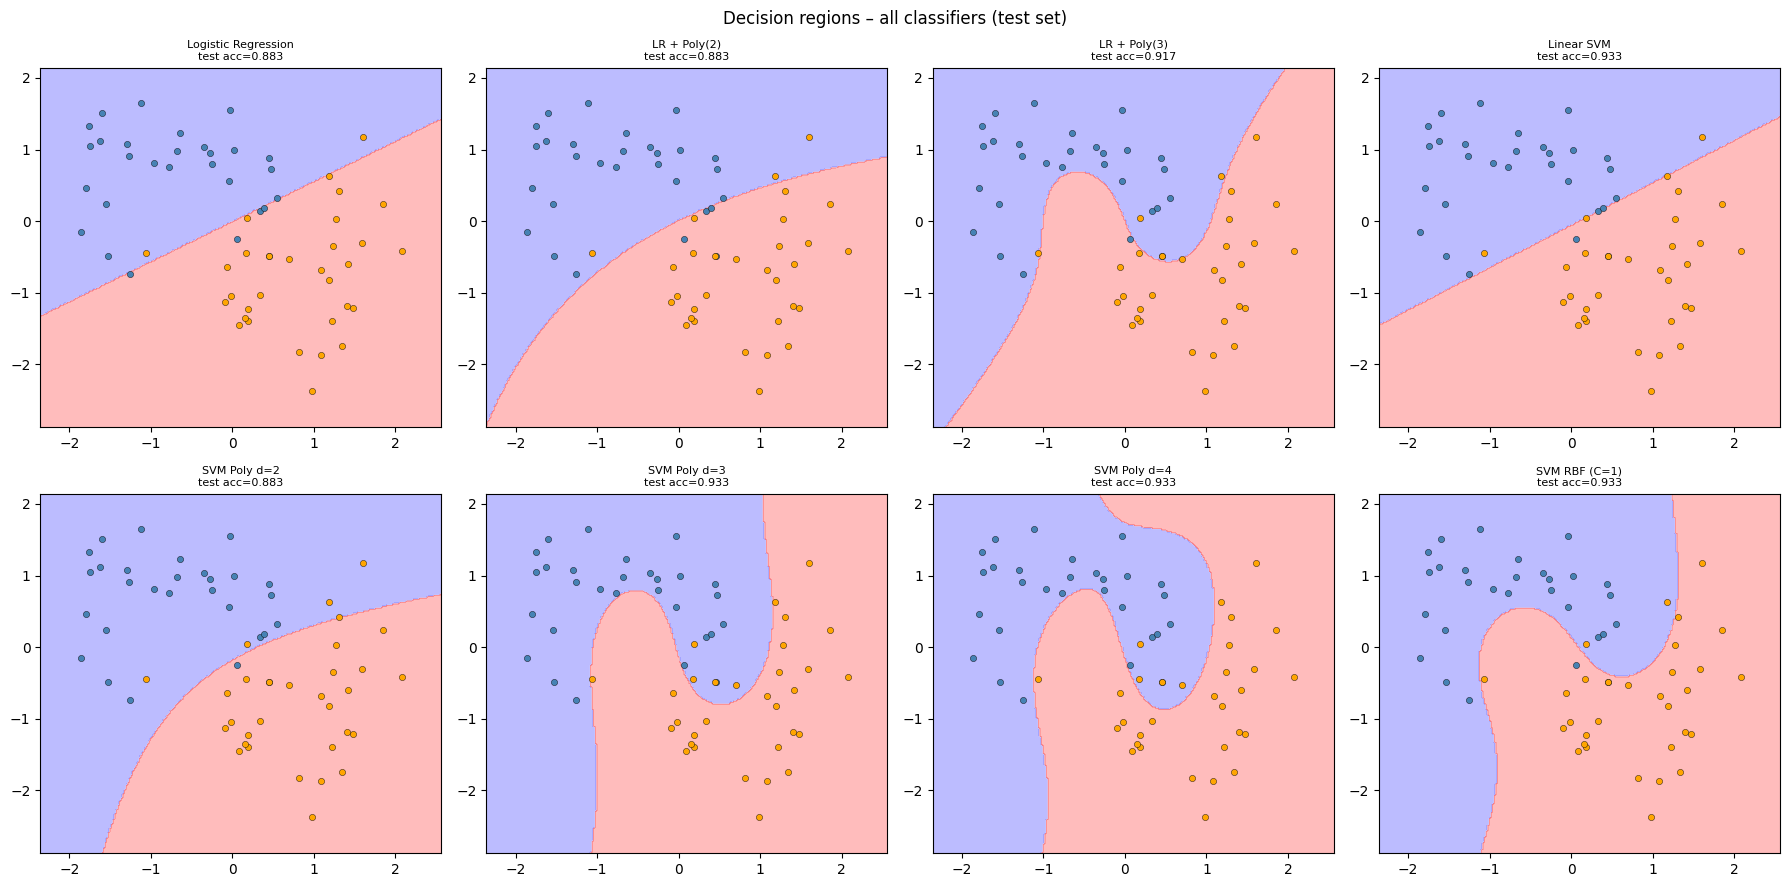

In [12]:
def plot_dr(X, y, clf, ax, title, resolution=0.02):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, resolution),
                         np.arange(x1_min, x1_max, resolution))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', s=20,
               edgecolors='k', linewidths=0.3, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='orange', s=20,
               edgecolors='k', linewidths=0.3, label='Class 1')
    te = accuracy_score(y, clf.predict(X))
    ax.set_title(f'{title}\ntest acc={te:.3f}', fontsize=8)

n_clf = len(classifiers)
ncols = 4
nrows = (n_clf + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.5))
axes = axes.ravel()
for i, (name, clf) in enumerate(classifiers.items()):
    plot_dr(X2_te_sc, y2_te, clf, axes[i], name)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Decision regions – all classifiers (test set)')
plt.tight_layout()
plt.show()

### RBF Kernel with Varying Gamma (C = 1)

   gamma   Train acc    Test acc
--------------------------------
    0.01      0.8125      0.8833
     0.1      0.8250      0.9000
       1      0.9417      0.9000
      10      0.9625      0.9167
     100      0.9875      0.8333


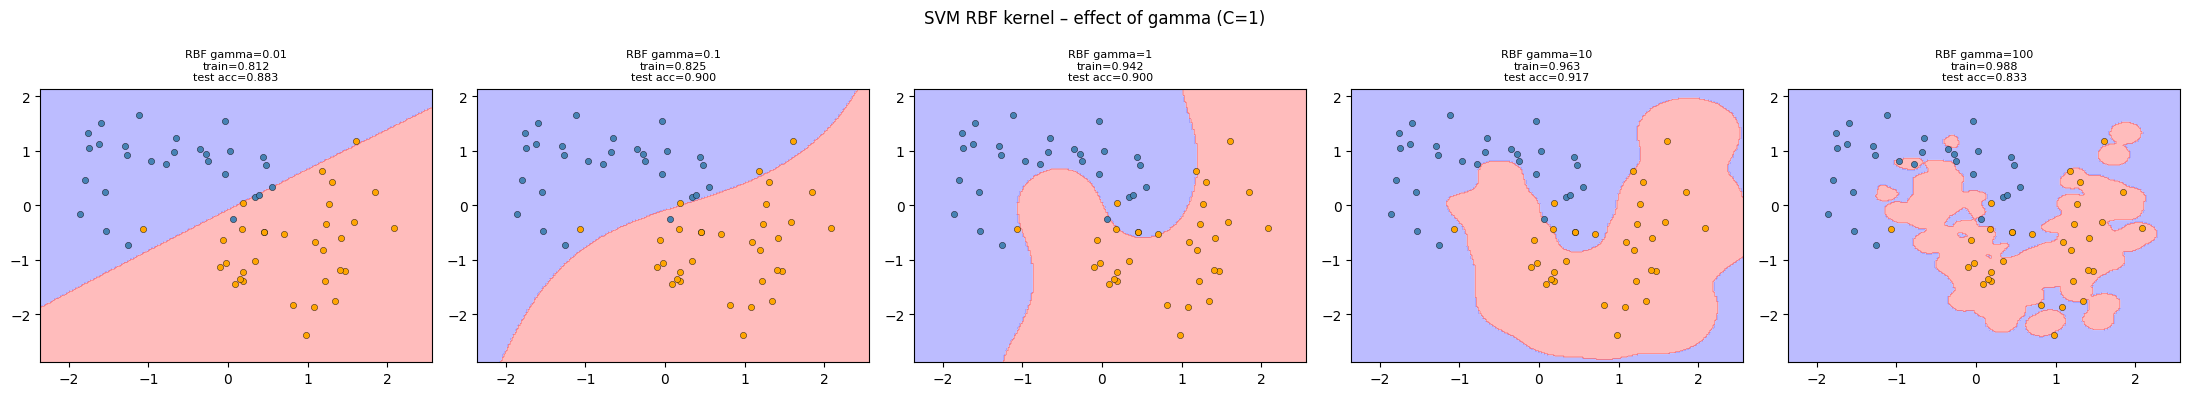

In [13]:
gammas = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, len(gammas), figsize=(22, 4))

print('{:>8}  {:>10}  {:>10}'.format('gamma', 'Train acc', 'Test acc'))
print('-' * 32)
for ax, gamma in zip(axes, gammas):
    clf = SVC(kernel='rbf', C=1, gamma=gamma)
    clf.fit(X2_tr_sc, y2_tr)
    tr = accuracy_score(y2_tr, clf.predict(X2_tr_sc))
    te = accuracy_score(y2_te, clf.predict(X2_te_sc))
    print(f'{gamma:>8}  {tr:>10.4f}  {te:>10.4f}')
    plot_dr(X2_te_sc, y2_te, clf, ax, f'RBF gamma={gamma}\ntrain={tr:.3f}')

plt.suptitle('SVM RBF kernel – effect of gamma (C=1)')
plt.tight_layout()
plt.show()

### Questions and Answers

**(a) Why do ordinary logistic regression and linear SVM perform poorly on this dataset?**

The moons dataset cannot be separated by a straight line because the two classes form interleaved crescent shapes. Both methods can only draw straight decision boundaries, so they fundamentally cannot fit this data well.

**(b) Does logistic regression with polynomial features of degree 3 produce a proper decision boundary?**

Yes. Adding degree-3 polynomial features gives the model enough flexibility to draw curved boundaries that follow the crescent shapes, resulting in much higher accuracy than the plain linear version.

**(c) What does the RBF kernel allow the SVM to do?**

The RBF kernel lets the SVM draw smooth, curved decision boundaries without explicitly creating new features. It measures similarity between points based on their distance, allowing the model to capture complex, nonlinear shapes.

**(d) What happens when gamma is very small?**

The model becomes very smooth and almost linear, unable to capture the curved structure of the data — this is underfitting, with poor accuracy on both training and test sets.

**(e) What happens when gamma is very large?**

The model memorises the training data, wrapping a tiny decision region around each training point — this is overfitting, with near-perfect training accuracy but poor test accuracy.

**(f) Compare logistic regression with polynomial features and SVM with RBF kernel.**

Both approaches extend a linear classifier to handle nonlinear data. The key difference is that polynomial features must be explicitly computed and grow large quickly, while the RBF kernel handles the same idea implicitly and more efficiently. In practice, SVM with RBF is easier to tune since only two parameters need to be adjusted instead of choosing the right polynomial degree.